# DeepSense 6G V2V Scenario 36: Fully Annotated Dataset Walkthrough
### Complete Multi-Modal Sensor Specification, Feature Engineering, and Codebook Analysis
---
This interactive notebook provides an exhaustive inspection of the real **DeepSense 6G Scenario 36** dataset (24,799 samples across 124 continuous vehicle drives).

In [1]:
# Cell 1: Imports and Data Loading
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Loading scenario36.p and scenario36.csv...")
with open("scenario36.p", "rb") as f:
    pdata = pickle.load(f)

csv_df = pd.read_csv("scenario36.csv")
print(f"Pickle Keys: {len(pdata.keys())} keys | CSV Shape: {csv_df.shape} | Total Samples: {len(df):,}")

Loading scenario36.p and scenario36.csv...
Pickle Keys: 58 keys | CSV Shape: (24799, 58) | Total Samples: 24,799


## 1. Dataset Schema & Hardware Mapping
- **Unit 1 (Receiver Vehicle)**: Ford Transit van equipped with four 64-element 60 GHz mmWave phased arrays, forward-facing ZED2 RGB stereo camera, and RTK-GPS.
- **Unit 2 (Transmitter Vehicle)**: Lincoln MKZ vehicle transmitting an omnidirectional 60 GHz beacon signal with synchronized RTK-GPS.

In [2]:
# Cell 2: Feature Inspection & 256 Power Matrix Assembly
df = pd.DataFrame({
    "abs_index": pdata["abs_index"],
    "seq_index": pdata["seq_index"],
    "unit1_gps1_lat": pdata["unit1_gps1_lat"],
    "unit1_gps1_lon": pdata["unit1_gps1_lon"],
    "unit2_gps1_lat": pdata["unit2_gps1_lat"],
    "unit2_gps1_lon": pdata["unit2_gps1_lon"],
    "unit1_overall-beam": pdata["unit1_overall-beam"]
})

# Extract 256 Power Profile Vectors across 4 Subarrays
pwr1 = np.vstack(pdata["unit1_pwr1"])
pwr2 = np.vstack(pdata["unit1_pwr2"])
pwr3 = np.vstack(pdata["unit1_pwr3"])
pwr4 = np.vstack(pdata["unit1_pwr4"])
pwr_all = np.hstack([pwr1, pwr2, pwr3, pwr4])

print(f"Total Telemetry Rows: {len(df):,} | Power Matrix Dimensions: {pwr_all.shape}")
df.head(5)

Total Telemetry Rows: 24,799 | Power Matrix Dimensions: (24799, 256)


,abs_index,seq_index,unit1_gps1_lat,unit1_gps1_lon,unit2_gps1_lat,unit2_gps1_lon,unit1_overall-beam
0,2674,1,33.421706,-111.930171,33.421633,-111.930175,162
1,2675,1,33.421706,-111.930171,33.421633,-111.930175,161
2,2676,1,33.421706,-111.930171,33.421633,-111.930175,162
3,2677,1,33.421706,-111.930171,33.421633,-111.930175,162
4,2678,1,33.421706,-111.930171,33.421633,-111.930175,161


## 2. 12 Spatial Kinematic Features Formulation
The 12 spatial kinematic features capture relative position, Line-of-Sight Euclidean distance, azimuth bearing angles, angular rates, and range velocity:

In [3]:
# Cell 3: Spatial Kinematics Calculation
rel_lat = df["unit2_gps1_lat"] - df["unit1_gps1_lat"]
rel_lon = df["unit2_gps1_lon"] - df["unit1_gps1_lon"]
distance = np.sqrt(rel_lat**2 + rel_lon**2) * 111000.0
bearing = np.arctan2(rel_lon, rel_lat).astype(np.float32)

kin_df = pd.DataFrame({
    "rel_lat": rel_lat,
    "rel_lon": rel_lon,
    "distance_m": distance,
    "bearing_rad": bearing,
    "sin_bearing": np.sin(bearing),
    "cos_bearing": np.cos(bearing),
    "bearing_rate": np.gradient(bearing),
    "distance_rate": np.gradient(distance),
})

kin_df.describe().T[["mean", "std", "min", "50%", "max"]]

,mean,std,min,50%,max
rel_lat,-4.549833e-06,0.000573,-0.001419,-0.000008,0.002256
rel_lon,-1.265534e-04,0.000634,-0.002835,-0.000003,0.003851
distance_m,6.597786e+01,69.590125,3.770428,40.327563,429.063300
bearing_rad,-3.686960e-01,2.058389,-3.141478,-0.039652,3.141593
sin_bearing,-6.024739e-02,0.590405,-1.000000,-0.012284,1.000000
cos_bearing,-1.013948e-01,0.798468,-1.000000,-0.019618,1.000000
bearing_rate,-9.130982e-07,0.195694,-3.141501,0.000005,3.141512
distance_rate,2.067661e-04,1.559105,-146.675039,0.000000,19.364846


## 3. Visualizing 256-Element Beam Spectra & Codebook Geometry

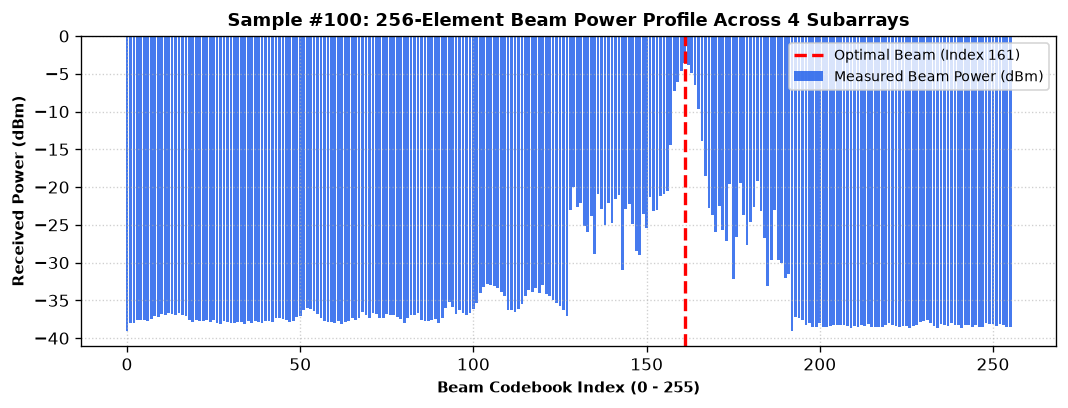

In [4]:
# Cell 4: 256-Beam Power Profile Visualization
sample_idx = 100
pwr_sample_linear = pwr_all[sample_idx]
pwr_sample_db = 10.0 * np.log10(pwr_sample_linear + 1e-12)
true_best_beam = int(df["unit1_overall-beam"].iloc[sample_idx])

fig, ax = plt.subplots(figsize=(9, 3.5), dpi=120)
ax.bar(range(256), pwr_sample_db, color='#2563EB', width=0.8, alpha=0.85, label='Measured Beam Power (dBm)')
ax.axvline(true_best_beam, color='red', linestyle='--', linewidth=2, label=f'Optimal Beam (Index {true_best_beam})')
ax.set_title(f'Sample #{sample_idx}: 256-Element Beam Power Profile Across 4 Subarrays', fontsize=11, fontweight='bold')
ax.set_xlabel('Beam Codebook Index (0 - 255)', fontsize=9, fontweight='bold')
ax.set_ylabel('Received Power (dBm)', fontsize=9, fontweight='bold')
ax.legend(loc='upper right', fontsize=8.5)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Trajectory Runs & Zero-Leakage Drive Partitions

Train Set:       86 drives | 17,199 samples (70.0%)
Calibration Set: 18 drives | 3,600 samples (15.0%)
Test Set:        20 drives | 4,000 samples (15.0%)


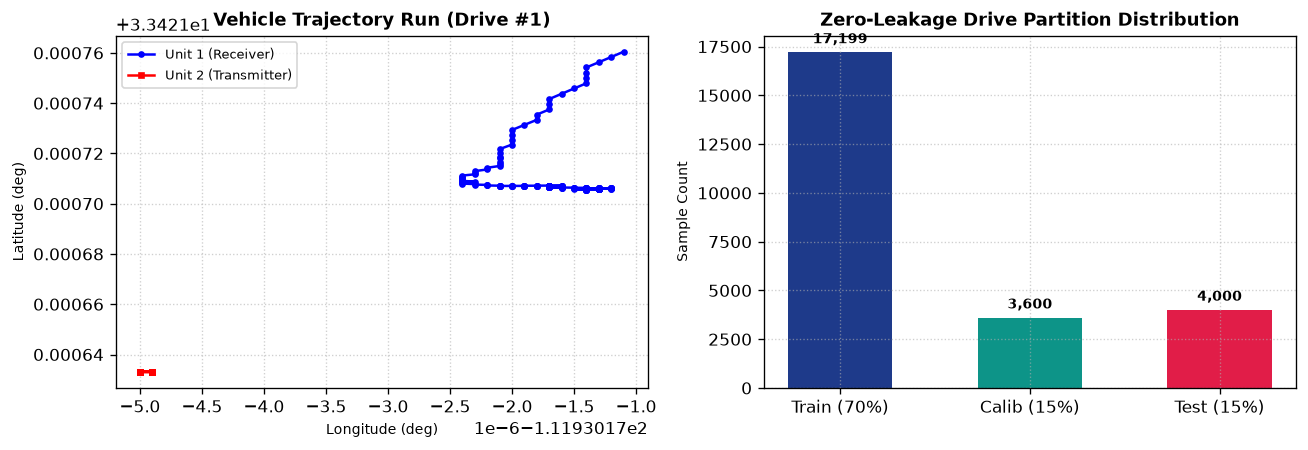

In [5]:
# Cell 5: Drive-Block Split & Trajectory Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), dpi=120)
drive_1 = df[df["seq_index"] == df["seq_index"].iloc[0]]
ax1.plot(drive_1["unit1_gps1_lon"], drive_1["unit1_gps1_lat"], 'b-o', markersize=3, label='Unit 1 (Receiver)')
ax1.plot(drive_1["unit2_gps1_lon"], drive_1["unit2_gps1_lat"], 'r-s', markersize=3, label='Unit 2 (Transmitter)')
ax1.set_title("Vehicle Trajectory Run (Drive #1)", fontsize=10.5, fontweight='bold')
ax1.set_xlabel("Longitude (deg)", fontsize=8.5)
ax1.set_ylabel("Latitude (deg)", fontsize=8.5)
ax1.legend(fontsize=8)
ax1.grid(True, linestyle=':', alpha=0.6)

drives = df["seq_index"].unique()
rng = np.random.default_rng(42)
rng.shuffle(drives)
n_tr = int(len(drives) * 0.70)
n_ca = int(len(drives) * 0.15)
train_drives = set(drives[:n_tr])
calib_drives = set(drives[n_tr:n_tr + n_ca])
test_drives = set(drives[n_tr + n_ca:])

counts = [
    len(df[df["seq_index"].isin(train_drives)]),
    len(df[df["seq_index"].isin(calib_drives)]),
    len(df[df["seq_index"].isin(test_drives)])
]
bars = ax2.bar(['Train (70%)', 'Calib (15%)', 'Test (15%)'], counts, color=['#1E3A8A', '#0D9488', '#E11D48'], width=0.55)
ax2.set_title("Zero-Leakage Drive Partition Distribution", fontsize=10.5, fontweight='bold')
ax2.set_ylabel("Sample Count", fontsize=8.5)
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 300, f"{yval:,}", ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Train Set:       {len(train_drives)} drives | {counts[0]:,} samples (70.0%)")
print(f"Calibration Set: {len(calib_drives)} drives | {counts[1]:,} samples (15.0%)")
print(f"Test Set:        {len(test_drives)} drives | {counts[2]:,} samples (15.0%)")